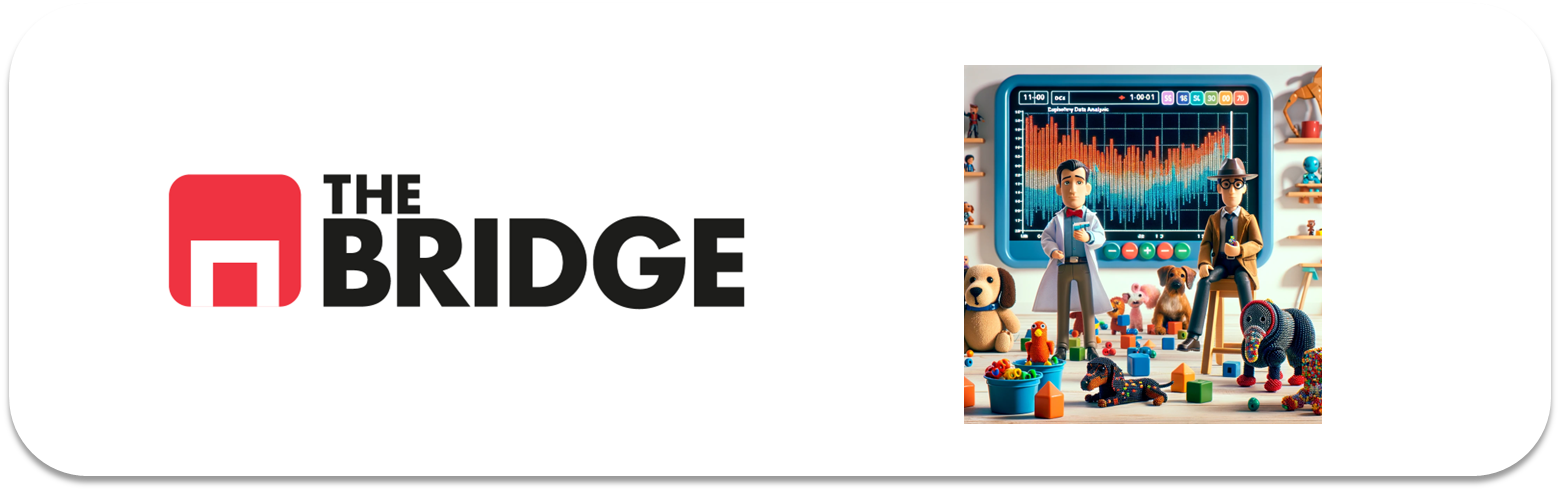

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df_titanic = pd.read_csv("./data/titanic.csv")

In [3]:
df = df_titanic.copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum

<bound method DataFrame.sum of      survived  pclass    sex    age  sibsp  parch   fare  embarked  class  \
0       False   False  False  False  False  False  False     False  False   
1       False   False  False  False  False  False  False     False  False   
2       False   False  False  False  False  False  False     False  False   
3       False   False  False  False  False  False  False     False  False   
4       False   False  False  False  False  False  False     False  False   
..        ...     ...    ...    ...    ...    ...    ...       ...    ...   
886     False   False  False  False  False  False  False     False  False   
887     False   False  False  False  False  False  False     False  False   
888     False   False  False   True  False  False  False     False  False   
889     False   False  False  False  False  False  False     False  False   
890     False   False  False  False  False  False  False     False  False   

       who  adult_male   deck  embark_town  

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [5]:
df.drop(columns=["deck","survived","pclass","embarked"], inplace= True)

In [7]:
df.columns

Index(['sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone'],
      dtype='str')

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [8]:
df["family_members"] = df.parch + df.sibsp

In [9]:
df.drop(columns=["sibsp","parch"], inplace= True)

In [10]:
df.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [14]:
embark_town_mode = df["embark_town"].mode()[0]
print(f"Moda: {embark_town_mode}")
print(f"Nulos: {df["embark_town"].isna().sum()}")

Moda: Southampton
Nulos: 0


In [15]:
df["embark_town"] = df["embark_town"].fillna(embark_town_mode)
print(f"Nulos: {df["embark_town"].isna().sum()}")

Nulos: 0


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [23]:
# Imputo el valor por who en age:

# Columna con flags de imputación
df["age_imputed"] = df.age.isna()

# Máscaras por género
is_woman = df.who == "woman"
is_child = df.who == "child"
is_man = df.who == "man"

# Valores medianos
mediana_woman = df.loc[is_woman,"age"].median()
mediana_child = df.loc[is_child,"age"].median() # No hay chiquillos nulos, pero por si acaso...
mediana_man = df.loc[is_man,"age"].median()

# Imputamos
df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man & df["age_imputed"], "age"] = mediana_man

In [24]:
# dataset limpio
df.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,age_imputed
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1,False
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1,False
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0,False
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1,False
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0,False


In [26]:
print(df.shape)
print(df.isna().sum().sum())

(891, 11)
0


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. Analisis univariante

In [31]:
# Categóricas

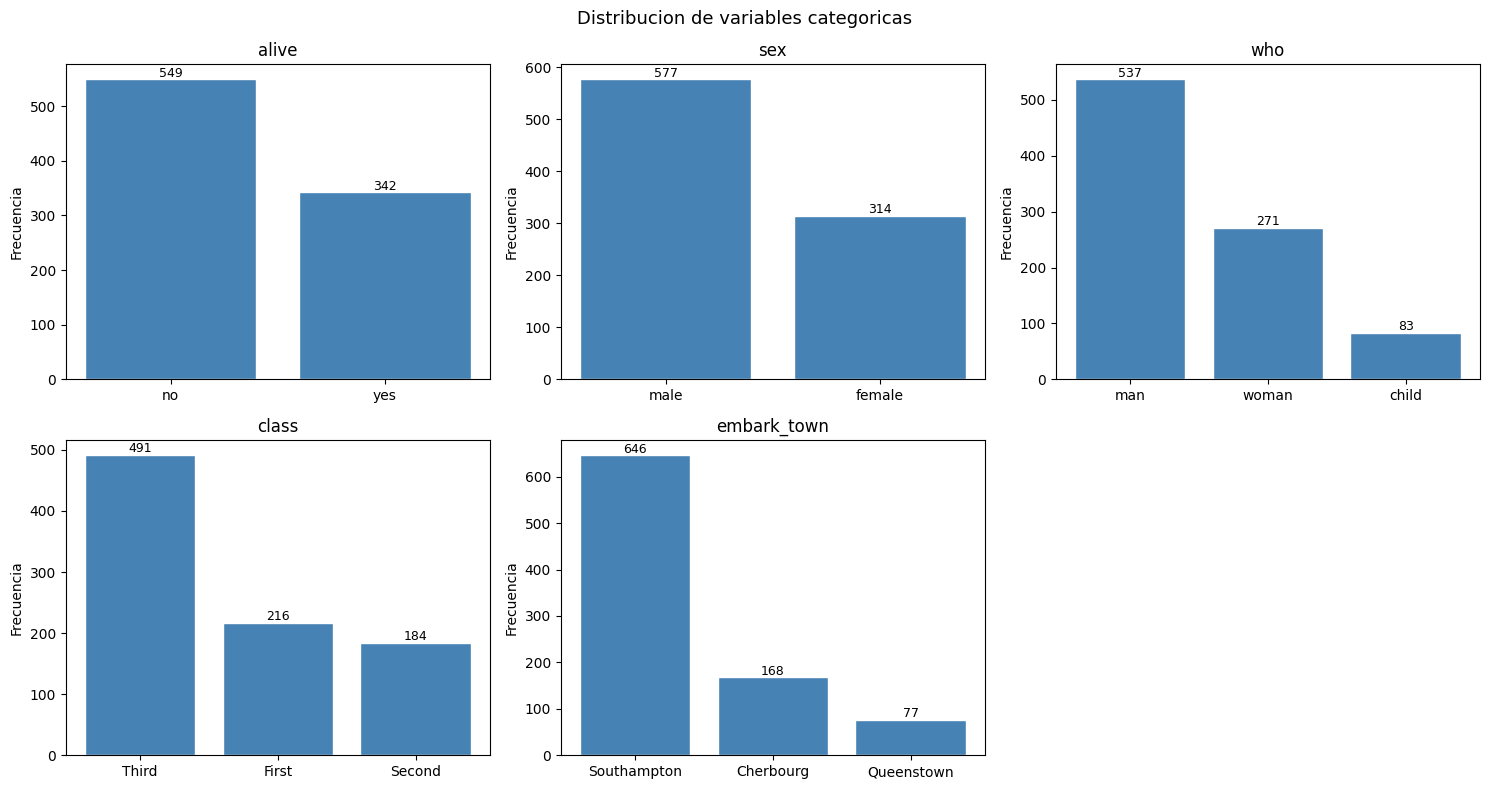

In [30]:
cat_cols = ["alive", "sex", "who", "class", "embark_town"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Frecuencia")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontsize=9)

axes[5].set_visible(False)
plt.suptitle("Distribucion de variables categoricas", fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Numéricas

In [33]:
num_cols = ["age", "fare", "family_members"]

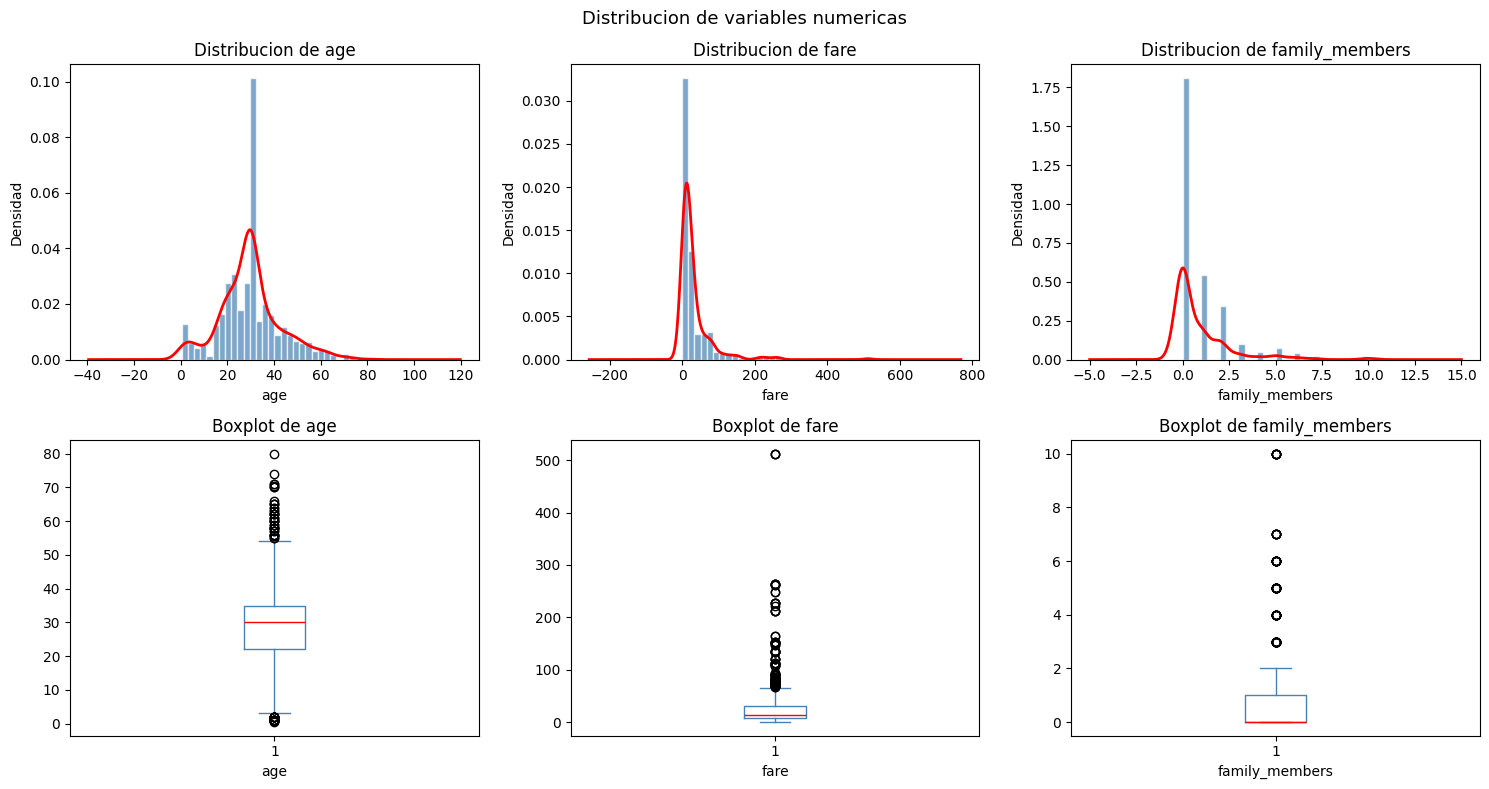

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histograma + densidad
    axes[0, i].hist(df[col], bins=30, color="steelblue", edgecolor="white", density=True, alpha=0.7)
    df[col].plot.kde(ax=axes[0, i], color="red", lw=2)
    axes[0, i].set_title(f"Distribucion de {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Densidad")

    # Boxplot
    axes[1, i].boxplot(df[col], vert=True,
                       boxprops=dict(color="steelblue"),
                       medianprops=dict(color="red"),
                       whiskerprops=dict(color="steelblue"),
                       capprops=dict(color="steelblue"))
    axes[1, i].set_title(f"Boxplot de {col}")
    axes[1, i].set_xlabel(col)

plt.suptitle("Distribucion de variables numericas", fontsize=13)
plt.tight_layout()
plt.show()

2. Analisis bivariante

In [35]:
# Tabla de contingencia
ct_who = pd.crosstab(df["who"], df["alive"])
ct_who_rel = pd.crosstab(df["who"], df["alive"], normalize="index").round(3)

print("Frecuencias absolutas:")
print(ct_who)
print("\nFrecuencias relativas (por fila):")
print(ct_who_rel)

Frecuencias absolutas:
alive   no  yes
who            
child   34   49
man    449   88
woman   66  205

Frecuencias relativas (por fila):
alive     no    yes
who                
child  0.410  0.590
man    0.836  0.164
woman  0.244  0.756


In [36]:
chi2_who, p_who, dof_who, _ = stats.chi2_contingency(ct_who)
print(f"Chi-cuadrado (who vs alive): chi2 = {chi2_who:.3f}, p = {p_who:.2e}, dof = {dof_who}")
print(f"Conclusion: {'Relacion estadisticamente significativa (p < 0.05)' if p_who < 0.05 else 'No significativa'}")

# Adulto vs niño (binario)
df["is_child"] = (df["who"] == "child").map({True: "child", False: "adult"})
ct_child = pd.crosstab(df["is_child"], df["alive"])
chi2_child, p_child, _, _ = stats.chi2_contingency(ct_child)
print(f"\nChi-cuadrado (adulto vs nino): chi2 = {chi2_child:.3f}, p = {p_child:.4f}")
print(f"Conclusion: {'Relacion estadisticamente significativa (p < 0.05)' if p_child < 0.05 else 'No significativa'}")

Chi-cuadrado (who vs alive): chi2 = 283.923, p = 2.22e-62, dof = 2
Conclusion: Relacion estadisticamente significativa (p < 0.05)

Chi-cuadrado (adulto vs nino): chi2 = 15.557, p = 0.0001
Conclusion: Relacion estadisticamente significativa (p < 0.05)


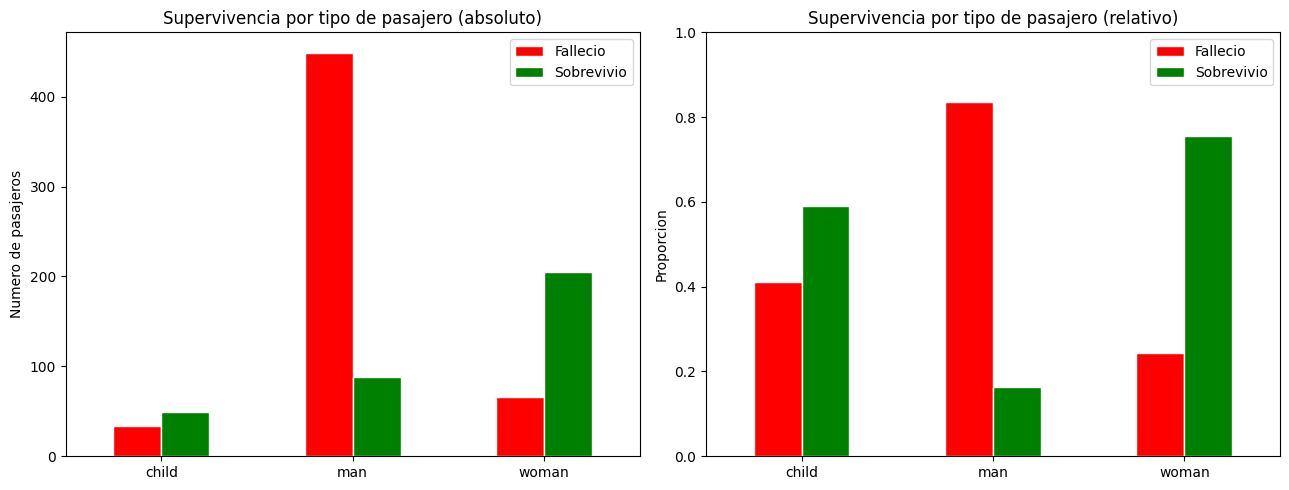

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolutos
ct_who.plot(kind="bar", ax=axes[0], color=["red", "green"], edgecolor="white")
axes[0].set_title("Supervivencia por tipo de pasajero (absoluto)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Numero de pasajeros")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Fallecio", "Sobrevivio"])

# Relativos
ct_who_rel.plot(kind="bar", ax=axes[1], color=["red", "green"], edgecolor="white")
axes[1].set_title("Supervivencia por tipo de pasajero (relativo)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Fallecio", "Sobrevivio"])
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

In [41]:
ct_class = pd.crosstab(df["class"], df["alive"])
ct_class_rel = pd.crosstab(df["class"], df["alive"], normalize="index").round(3)

print("Frecuencias absolutas:")
print(ct_class)
print("\nFrecuencias relativas (por fila):")
print(ct_class_rel)

chi2_class, p_class, dof_class, _ = stats.chi2_contingency(ct_class)
print(f"\nChi-cuadrado: chi2 = {chi2_class:.3f}, p = {p_class:.2e}, dof = {dof_class}")
print(f"Conclusion: {'Relacion estadisticamente significativa (p < 0.05)' if p_class < 0.05 else 'No significativa'}")

Frecuencias absolutas:
alive    no  yes
class           
First    80  136
Second   97   87
Third   372  119

Frecuencias relativas (por fila):
alive      no    yes
class               
First   0.370  0.630
Second  0.527  0.473
Third   0.758  0.242

Chi-cuadrado: chi2 = 102.889, p = 4.55e-23, dof = 2
Conclusion: Relacion estadisticamente significativa (p < 0.05)


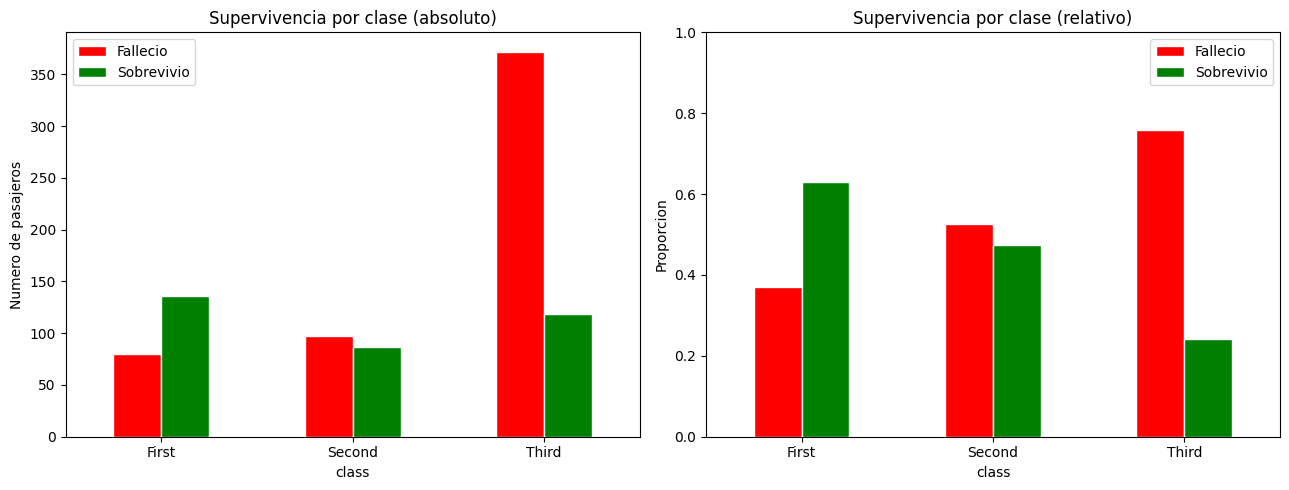

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_class.plot(kind="bar", ax=axes[0], color=["red", "green"], edgecolor="white")
axes[0].set_title("Supervivencia por clase (absoluto)")
axes[0].set_ylabel("Numero de pasajeros")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Fallecio", "Sobrevivio"])

ct_class_rel.plot(kind="bar", ax=axes[1], color=["red", "green"], edgecolor="white")
axes[1].set_title("Supervivencia por clase (relativo)")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Fallecio", "Sobrevivio"])
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?


In [43]:
ct_emb = pd.crosstab(df["embark_town"], df["alive"])
ct_emb_rel = pd.crosstab(df["embark_town"], df["alive"], normalize="index").round(3)

print("Frecuencias absolutas:")
print(ct_emb)
print("\nFrecuencias relativas (por fila):")
print(ct_emb_rel)

chi2_emb, p_emb, dof_emb, _ = stats.chi2_contingency(ct_emb)
print(f"\nChi-cuadrado: chi2 = {chi2_emb:.3f}, p = {p_emb:.4f}, dof = {dof_emb}")
print(f"Conclusion: {'Relacion estadisticamente significativa (p < 0.05)' if p_emb < 0.05 else 'No significativa'}")

Frecuencias absolutas:
alive         no  yes
embark_town          
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219

Frecuencias relativas (por fila):
alive           no    yes
embark_town              
Cherbourg    0.446  0.554
Queenstown   0.610  0.390
Southampton  0.661  0.339

Chi-cuadrado: chi2 = 25.964, p = 0.0000, dof = 2
Conclusion: Relacion estadisticamente significativa (p < 0.05)


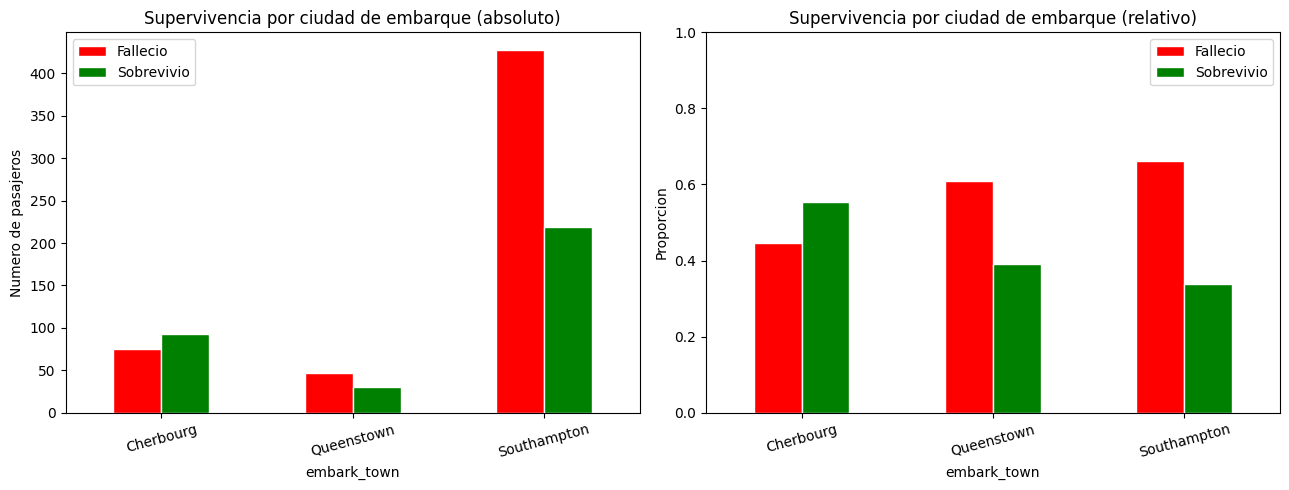

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_emb.plot(kind="bar", ax=axes[0], color=["red", "green"], edgecolor="white")
axes[0].set_title("Supervivencia por ciudad de embarque (absoluto)")
axes[0].set_ylabel("Numero de pasajeros")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(["Fallecio", "Sobrevivio"])

ct_emb_rel.plot(kind="bar", ax=axes[1], color=["red", "green"], edgecolor="white")
axes[1].set_title("Supervivencia por ciudad de embarque (relativo)")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(["Fallecio", "Sobrevivio"])
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?


In [49]:
fare_yes = df[df["alive"] == "yes"]["fare"]
fare_no  = df[df["alive"] == "no"]["fare"]

print("Precio del billete segun supervivencia:")
print(f"  Sobrevivio  — Media: {fare_yes.mean():.2f}  Mediana: {fare_yes.median():.2f}  Std: {fare_yes.std():.2f}")
print(f"  Fallecio    — Media: {fare_no.mean():.2f}   Mediana: {fare_no.median():.2f}   Std: {fare_no.std():.2f}")

U, p_mw = stats.mannwhitneyu(fare_yes, fare_no, alternative="two-sided")
print(f"\nMann-Whitney U = {U:.0f},  p = {p_mw:.2e}")
print(f"Conclusion: {'Diferencia estadisticamente significativa (p < 0.05)' if p_mw < 0.05 else 'No significativa'}")

Precio del billete segun supervivencia:
  Sobrevivio  — Media: 48.40  Mediana: 26.00  Std: 66.60
  Fallecio    — Media: 22.12   Mediana: 10.50   Std: 31.39

Mann-Whitney U = 129952,  p = 4.55e-22
Conclusion: Diferencia estadisticamente significativa (p < 0.05)


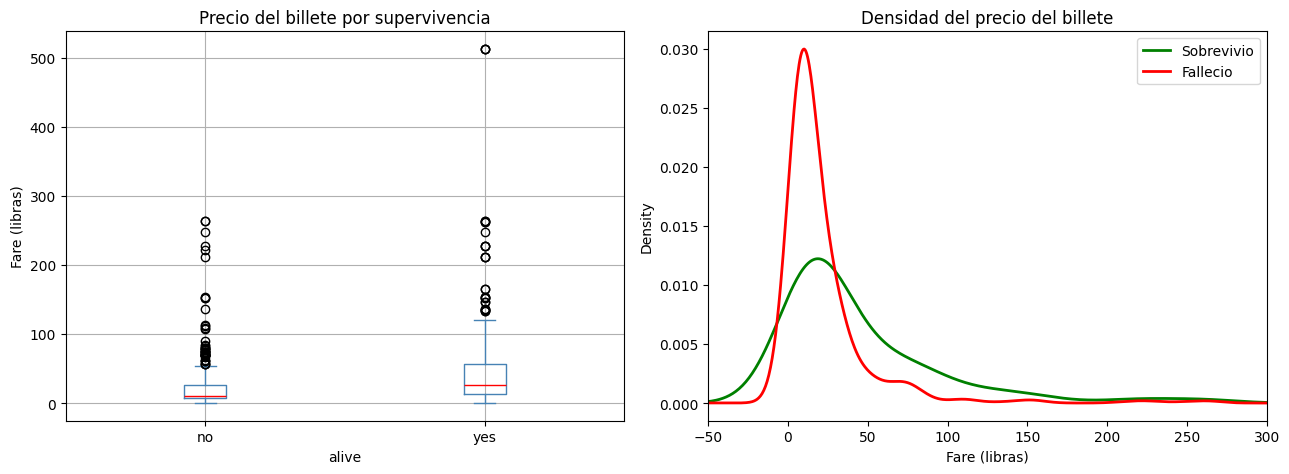

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
df.boxplot(column="fare", by="alive", ax=axes[0],
           boxprops=dict(color="steelblue"), medianprops=dict(color="red"),
           whiskerprops=dict(color="steelblue"), capprops=dict(color="steelblue"))
axes[0].set_title("Precio del billete por supervivencia")
axes[0].set_xlabel("alive")
axes[0].set_ylabel("Fare (libras)")
plt.sca(axes[0])
plt.title("Precio del billete por supervivencia")

# Densidad superpuesta
fare_yes.plot.kde(ax=axes[1], label="Sobrevivio", color="green", lw=2)
fare_no.plot.kde(ax=axes[1], label="Fallecio", color="red", lw=2)
axes[1].set_title("Densidad del precio del billete")
axes[1].set_xlabel("Fare (libras)")
axes[1].set_xlim(-50, 300)
axes[1].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()


5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?


In [51]:
fare_cero = df[df["fare"] == 0][["sex","age","who","class","embark_town","alive","fare"]]

print(f"Pasajeros con fare = 0: {len(fare_cero)}")
print()
print(fare_cero.to_string())

Pasajeros con fare = 0: 15

      sex   age  who   class  embark_town alive  fare
179  male  36.0  man   Third  Southampton    no   0.0
263  male  40.0  man   First  Southampton    no   0.0
271  male  25.0  man   Third  Southampton   yes   0.0
277  male  30.0  man  Second  Southampton    no   0.0
302  male  19.0  man   Third  Southampton    no   0.0
413  male  30.0  man  Second  Southampton    no   0.0
466  male  30.0  man  Second  Southampton    no   0.0
481  male  30.0  man  Second  Southampton    no   0.0
597  male  49.0  man   Third  Southampton    no   0.0
633  male  30.0  man   First  Southampton    no   0.0
674  male  30.0  man  Second  Southampton    no   0.0
732  male  30.0  man  Second  Southampton    no   0.0
806  male  39.0  man   First  Southampton    no   0.0
815  male  30.0  man   First  Southampton    no   0.0
822  male  38.0  man   First  Southampton    no   0.0


In [52]:
print("Perfil de los pasajeros con fare = 0:")
print(f"  Todos son:   {fare_cero['sex'].unique()}")
print(f"  Ciudad:      {fare_cero['embark_town'].unique()}")
print(f"  Clases:      {fare_cero['class'].value_counts().to_dict()}")
print(f"  Sobrevivieron: {fare_cero['alive'].value_counts().to_dict()}")

Perfil de los pasajeros con fare = 0:
  Todos son:   <StringArray>
['male']
Length: 1, dtype: str
  Ciudad:      <StringArray>
['Southampton']
Length: 1, dtype: str
  Clases:      {'Second': 6, 'First': 5, 'Third': 4}
  Sobrevivieron: {'no': 14, 'yes': 1}


In [53]:
max_fare = df["fare"].max()
top_fare = df[df["fare"] == max_fare][["sex","age","who","class","embark_town","alive","fare"]]

print(f"Precio maximo del billete: {max_fare:.4f} libras")
print()
print(top_fare.to_string())

Precio maximo del billete: 512.3292 libras

        sex   age    who  class embark_town alive      fare
258  female  35.0  woman  First   Cherbourg   yes  512.3292
679    male  36.0    man  First   Cherbourg   yes  512.3292
737    male  35.0    man  First   Cherbourg   yes  512.3292



6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muéstralo numérica o visualmente.


In [54]:
resumen = df.groupby(["embark_town", "alive"])["fare"].agg(["median","mean","count"]).round(2)
print("Precio del billete por ciudad y supervivencia:")
print(resumen.to_string())

Precio del billete por ciudad y supervivencia:
                   median   mean  count
embark_town alive                      
Cherbourg   no      14.46  35.44     75
            yes     56.93  79.72     93
Queenstown  no       7.75  13.34     47
            yes      7.81  13.18     30
Southampton no      10.50  20.74    427
            yes     26.00  39.92    219


C:\Users\PC\AppData\Local\Temp\ipykernel_21148\2209869869.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_plot, labels=labels, patch_artist=True)


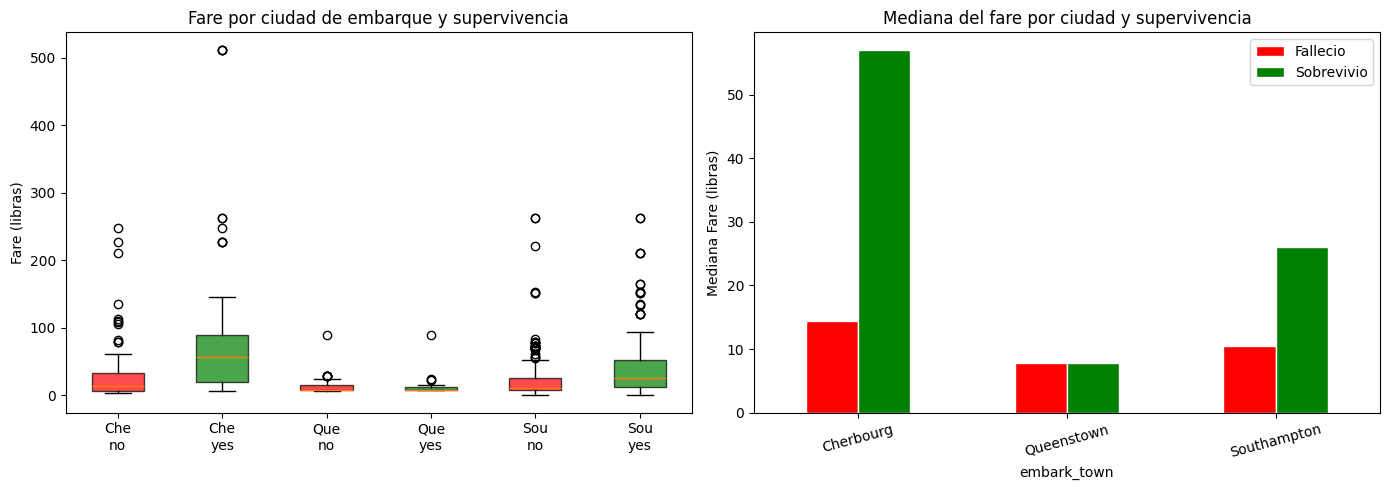

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot fare por ciudad y supervivencia
cities = df["embark_town"].unique()
data_plot = [
    df[(df["embark_town"] == c) & (df["alive"] == a)]["fare"]
    for c in sorted(cities)
    for a in ["no", "yes"]
]
labels = [f"{c[:3]}\n{a}" for c in sorted(cities) for a in ["no", "yes"]]
bp = axes[0].boxplot(data_plot, labels=labels, patch_artist=True)
colors = ["red", "green"] * 3
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Fare por ciudad de embarque y supervivencia")
axes[0].set_ylabel("Fare (libras)")

# Mediana del fare por ciudad y supervivencia
medians = df.groupby(["embark_town", "alive"])["fare"].median().unstack()
medians.plot(kind="bar", ax=axes[1], color=["red", "green"], edgecolor="white")
axes[1].set_title("Mediana del fare por ciudad y supervivencia")
axes[1].set_ylabel("Mediana Fare (libras)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(["Fallecio", "Sobrevivio"])

plt.tight_layout()
plt.show()


7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?


In [57]:
df["alive_bin"] = (df["alive"] == "yes").astype(int)

tabla = df.groupby(["class", "who"])["alive_bin"].agg(
    Sobrevivieron="sum",
    Total="count"
)
tabla["Tasa_supervivencia"] = (tabla["Sobrevivieron"] / tabla["Total"]).round(3)

print("Supervivencia por clase y tipo de pasajero:")
print(tabla.to_string())

Supervivencia por clase y tipo de pasajero:
              Sobrevivieron  Total  Tasa_supervivencia
class  who                                            
First  child              5      6               0.833
       man               42    119               0.353
       woman             89     91               0.978
Second child             19     19               1.000
       man                8     99               0.081
       woman             60     66               0.909
Third  child             25     58               0.431
       man               38    319               0.119
       woman             56    114               0.491


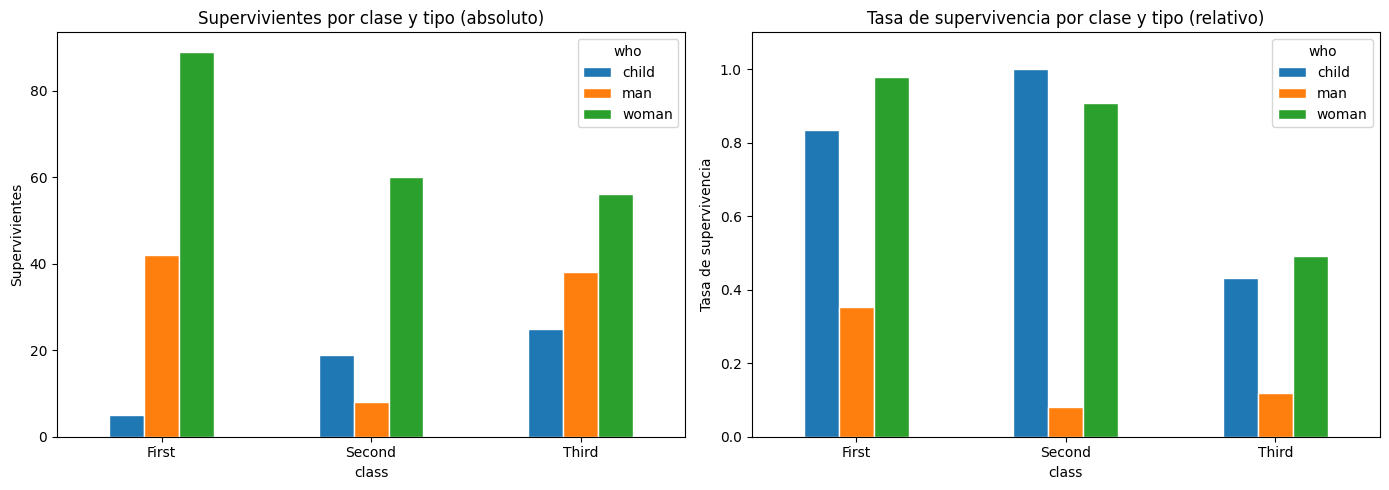

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolutos
piv_abs = tabla["Sobrevivieron"].unstack()
piv_abs.plot(kind="bar", ax=axes[0], edgecolor="white")
axes[0].set_title("Supervivientes por clase y tipo (absoluto)")
axes[0].set_ylabel("Supervivientes")
axes[0].tick_params(axis="x", rotation=0)

# Tasas
piv_rel = tabla["Tasa_supervivencia"].unstack()
piv_rel.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("Tasa de supervivencia por clase y tipo (relativo)")
axes[1].set_ylabel("Tasa de supervivencia")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [59]:
# Correlacion Pearson entre age y fare (ambas numericas continuas)
r, p_r = stats.pearsonr(df["age"], df["fare"])
print(f"Correlacion Pearson (age vs fare): r = {r:.3f},  p = {p_r:.4f}")

# Mann-Whitney: age vs alive
age_yes = df[df["alive"] == "yes"]["age"]
age_no  = df[df["alive"] == "no"]["age"]
U_age, p_age = stats.mannwhitneyu(age_yes, age_no, alternative="two-sided")
print(f"\nEdad media sobrevivio: {age_yes.mean():.1f}  |  Edad media fallecio: {age_no.mean():.1f}")
print(f"Mann-Whitney (age vs alive): U = {U_age:.0f},  p = {p_age:.4f}")
print(f"Conclusion: {'Diferencia significativa (p < 0.05)' if p_age < 0.05 else 'No significativa'}")

Correlacion Pearson (age vs fare): r = 0.091,  p = 0.0068

Edad media sobrevivio: 28.6  |  Edad media fallecio: 30.5
Mann-Whitney (age vs alive): U = 89303,  p = 0.2179
Conclusion: No significativa


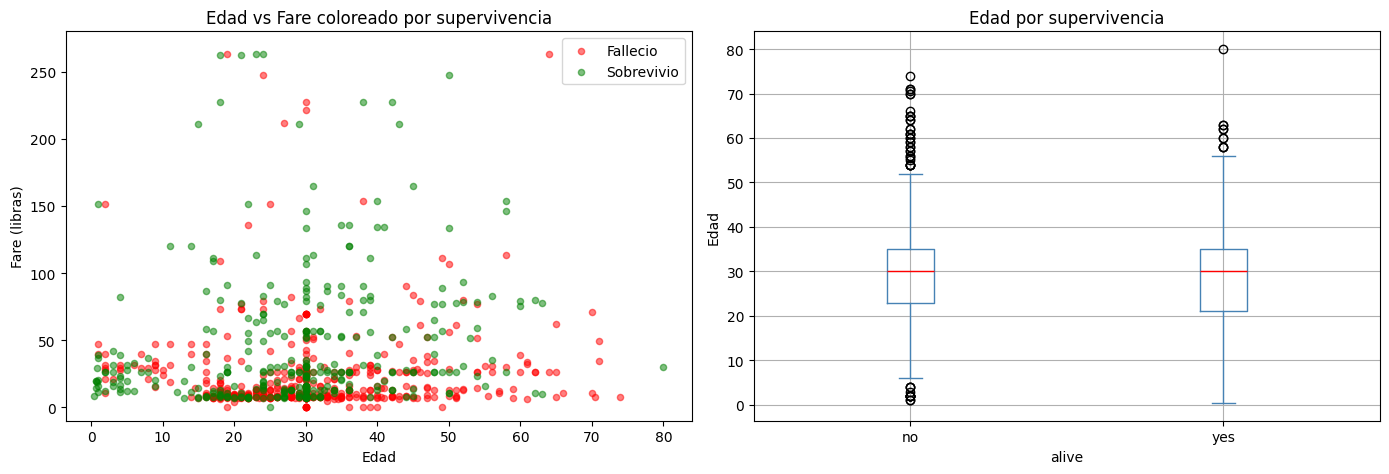

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter age vs fare coloreado por alive
colors_map = {"yes": "green", "no": "red"}
for label, group in df.groupby("alive"):
    axes[0].scatter(
        group["age"], group["fare"],
        c=colors_map[label],
        label="Sobrevivio" if label == "yes" else "Fallecio",
        alpha=0.5, s=20
    )
axes[0].set_title("Edad vs Fare coloreado por supervivencia")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Fare (libras)")
axes[0].legend()
axes[0].set_ylim(-10, 280)

# Boxplot edad por supervivencia
df.boxplot(column="age", by="alive", ax=axes[1],
           boxprops=dict(color="steelblue"), medianprops=dict(color="red"),
           whiskerprops=dict(color="steelblue"), capprops=dict(color="steelblue"))
axes[1].set_title("Edad por supervivencia")
axes[1].set_xlabel("alive")
axes[1].set_ylabel("Edad")
plt.sca(axes[1])
plt.title("Edad por supervivencia")

plt.suptitle("")
plt.tight_layout()
plt.show()

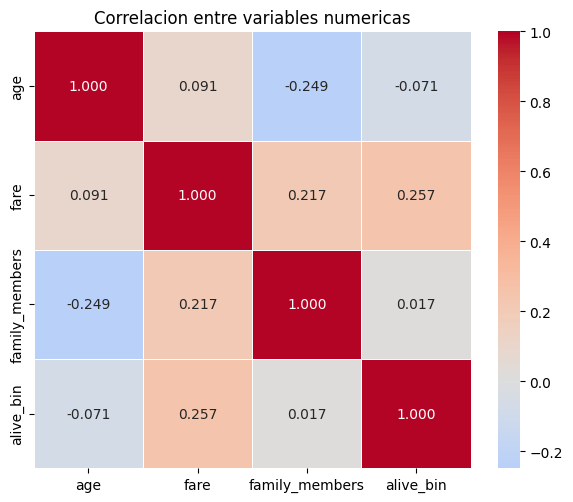

In [62]:
# Correlacion entre variables numericas (age, fare, family_members)
corr_matrix = df[["age", "fare", "family_members", "alive_bin"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?